# SPACESHIP TITANIC

In [365]:
import copy
import random
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xgb

from torch.utils.data import TensorDataset, DataLoader
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression


## Data Import

In [366]:
train_data = pd.read_csv("./data/train.csv")
test_data = pd.read_csv("./data/test.csv")

## Data Preprocess
- Transported/CryoSleep 轉成 0/1
- PassengerId、Name、Cabin 原始欄位不直接當特徵
- PassengerId / Name 會衍生群組特徵
- RoomService / FoodCourt / ShoppingMall / Spa / VRDeck 會衍生消費聚合特徵
- Age 會另外切成幾個 age bins
- 也會加入 missingness 訊號與少量交互特徵，例如 CryoSleep x Spend、HomePlanet x Destination、CabinDeck x CabinSide
- Cabin 缺失值補上 Missing//Missing
    - 把 Cabin 拆成 CabinDeck、CabinNum、CabinSide


In [367]:
def to_binary(series):
    return series.astype(str).map({"False": 0, "True": 1}).astype(float)


def add_basic_features(df):
    df = df.copy()

    # 先把原始欄位的缺失狀態顯式保留下來，讓模型知道「這格本來是空的」。
    missing_cols = ["HomePlanet", "CryoSleep", "Cabin", "Destination", "Age", "VIP", "RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck", "Name"]
    for col in missing_cols:
        df[f"{col}IsMissing"] = df[col].isna().astype(float)

    passenger_group = (
        df["PassengerId"]
        .astype("string")
        .fillna("Missing")
        .str.split("_", n=1, expand=True)[0]
    )
    passenger_group_size = passenger_group.map(passenger_group.value_counts()).astype(float)
    df["PassengerGroupSize"] = passenger_group_size
    df["PassengerIsAlone"] = (passenger_group_size == 1).astype(float)

    age_numeric = pd.to_numeric(df["Age"], errors="coerce")
    age_bins = [-np.inf, 12, 17, 25, 40, 60, np.inf]
    age_labels = ["Child", "Teen", "YoungAdult", "Adult", "MiddleAged", "Senior"]
    df["AgeBin"] = pd.cut(age_numeric, bins=age_bins, labels=age_labels, include_lowest=True).astype("string").fillna("Missing")

    surname = (
        df["Name"]
        .astype("string")
        .fillna("Missing")
        .str.rsplit(" ", n=1)
        .str[-1]
    )
    surname_group_size = surname.map(surname.value_counts()).astype(float)
    df["SurnameGroupSize"] = surname_group_size
    df["SurnameIsAlone"] = (surname_group_size == 1).astype(float)

    spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
    spend_frame = df[spend_cols].fillna(0)
    df["TotalSpend"] = spend_frame.sum(axis=1)
    df["LogTotalSpend"] = np.log1p(df["TotalSpend"])
    df["AnySpend"] = (df["TotalSpend"] > 0).astype(float)
    df["LuxurySpend"] = spend_frame[["Spa", "VRDeck"]].sum(axis=1)
    df["RegularSpend"] = spend_frame[["RoomService", "FoodCourt", "ShoppingMall"]].sum(axis=1)

    # 把幾個高訊號的交互關係顯式做出來，讓後面的模型更容易使用。
    cryo_binary = to_binary(df["CryoSleep"])
    df["CryoSleepTotalSpend"] = cryo_binary * df["TotalSpend"]
    df["AgeCryoSleep"] = cryo_binary * age_numeric
    df["SpendPerPassenger"] = df["TotalSpend"] / passenger_group_size

    home_planet = df["HomePlanet"].astype("string").fillna("Missing")
    destination = df["Destination"].astype("string").fillna("Missing")
    df["HomePlanetDestination"] = home_planet + "__" + destination

    df = df.drop(columns=["PassengerId", "Name"], errors="ignore")
    cabin = df["Cabin"].fillna("Missing//Missing").str.split("/", expand=True)
    df["CabinDeck"] = cabin[0]
    df["CabinNum"] = pd.to_numeric(cabin[1], errors="coerce")
    df["CabinSide"] = cabin[2]
    df["CabinDeckSide"] = df["CabinDeck"].astype("string") + "__" + df["CabinSide"].astype("string")
    return df.drop(columns=["Cabin"])


# Split train / validation first.
X = train_data.drop(columns=["Transported"]).copy()
y = to_binary(train_data["Transported"])
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

X_train = add_basic_features(X_train)
X_val = add_basic_features(X_val)


## Baseline 0
先看一個最簡單的 `Transported = CryoSleep` validation accuracy
- 把 validation set 裡 CryoSleep 的缺失值，補成算出的眾數

In [368]:
# 先從 training split 的 CryoSleep 找出最常出現的值
cryo_mode = X_train["CryoSleep"].mode(dropna=True)[0]
# 把 validation split 裡 CryoSleep 的缺失值，補成剛剛算出的眾數
cryo_val = X_val["CryoSleep"].astype("string").fillna(cryo_mode)
cryo_pred = to_binary(cryo_val)
# 直接算 accuracy
acc_b0 = accuracy_score(y_val, cryo_pred >= 0.5)
print(f"Baseline 0 | Transported = CryoSleep | Acc: {acc_b0:.4f}")

Baseline 0 | Transported = CryoSleep | Acc: 0.7131


## Baseline1
Ridge fit training split，再算 validation accuracy

In [369]:
# Baseline 1: Ridge on train split, evaluated on validation split.
numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=["number"]).columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")), # 數值欄位用 median 補缺失值
                ("scaler", StandardScaler()),
            ]),
            numeric_features,
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")), # 類別欄位用 most_frequent 補缺失值
                ("onehot", OneHotEncoder(handle_unknown="ignore")),
            ]),
            categorical_features,
        ),
    ]
)

model = Pipeline([
    ("preprocess", preprocess),
    ("ridge", Ridge(alpha=1.0)),
])

model.fit(X_train, y_train)
val_pred = model.predict(X_val)
acc_b1 = accuracy_score(y_val, val_pred >= 0.5)
print(f"Baseline 1 | Ridge val Acc: {acc_b1:.4f}")


Baseline 1 | Ridge val Acc: 0.7688


# XGBoost + Feature Selection + Early Stopping + k-Ensemble + OOF Threshold Search
- 先做缺值補齊 + one-hot
- 用 SelectKBest(f_regression) 選特徵
- 直接用外層 X_val 做 early stopping
- 再把不同 k 的模型平均，做 k-bagging
- 最後用 OOF 找 threshold 再做分類
- 畫 train / val logloss 曲線看收斂狀況

In [370]:
import xgboost as xgb



# XGBoost does not need scaling, so we only impute missing values and one-hot encode categoricals.
xgb_numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()
xgb_categorical_features = X_train.select_dtypes(exclude=["number"]).columns.tolist()

xgb_preprocess = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), xgb_numeric_features),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore")),
            ]),
            xgb_categorical_features,
        ),
    ]
)

X_train_pre = xgb_preprocess.fit_transform(X_train)
X_val_pre = xgb_preprocess.transform(X_val)
xgb_feature_names = xgb_preprocess.get_feature_names_out()

# Keep the feature screen compact, then let XGBoost learn on the selected columns.
XGB_SELECT_K = 40
N_ESTIMATORS = 10000
LR=0.01
MAX_DEPTH=5
SUBSAMPLE=0.65
COLSAMPLE_BYTREE=0.9
REG_LAMBDA=0.2
ESR=200


xgb_k = min(XGB_SELECT_K, X_train_pre.shape[1])
selector = SelectKBest(score_func=f_regression, k=xgb_k)
X_train_sel = selector.fit_transform(X_train_pre, y_train)
X_val_sel = selector.transform(X_val_pre)
selected_xgb_feature_names = xgb_feature_names[selector.get_support()]

print(f"XGB_SELECT_K = {xgb_k}")
print(f"preprocessed feature count = {X_train_pre.shape[1]}")
print(f"selected feature count = {len(selected_xgb_feature_names)}")
print("selected features:")
print(list(selected_xgb_feature_names))

def booster_predict_proba(booster, dmatrix):
    best_iteration = getattr(booster, "best_iteration", None)
    if best_iteration is not None:
        try:
            return booster.predict(dmatrix, iteration_range=(0, best_iteration + 1))
        except TypeError:
            best_ntree_limit = getattr(booster, "best_ntree_limit", None)
            if best_ntree_limit is not None:
                try:
                    return booster.predict(dmatrix, ntree_limit=best_ntree_limit)
                except TypeError:
                    pass
    return booster.predict(dmatrix)

dtrain = xgb.DMatrix(X_train_sel, label=y_train.astype(int))
dval = xgb.DMatrix(X_val_sel, label=y_val.astype(int))

xgb_params = {
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "max_depth": MAX_DEPTH,
    "eta": LR,
    "subsample": SUBSAMPLE,
    "colsample_bytree": COLSAMPLE_BYTREE,
    "lambda": REG_LAMBDA,
    "seed": 42,
    "verbosity": 0,
}
evals_result = {}
xgb_model = xgb.train(
    params=xgb_params,
    dtrain=dtrain,
    num_boost_round=N_ESTIMATORS,
    evals=[(dtrain, "validation_0"), (dval, "validation_1")],
    evals_result=evals_result,
    early_stopping_rounds=ESR,
    verbose_eval=False,
)
train_acc_xgb = accuracy_score(y_train.astype(int), booster_predict_proba(xgb_model, dtrain) >= 0.5)
val_acc_xgb = accuracy_score(y_val.astype(int), booster_predict_proba(xgb_model, dval) >= 0.5)
print(f"XGBoost | train acc: {train_acc_xgb:.4f} | val acc: {val_acc_xgb:.4f}")
print(f"best_iteration = {xgb_model.best_iteration}")
print(f"best_score = {xgb_model.best_score}")


XGB_SELECT_K = 40
preprocessed feature count = 93
selected feature count = 40
selected features:
['num__Age', 'num__RoomService', 'num__FoodCourt', 'num__Spa', 'num__VRDeck', 'num__PassengerGroupSize', 'num__PassengerIsAlone', 'num__TotalSpend', 'num__LogTotalSpend', 'num__AnySpend', 'num__LuxurySpend', 'num__RegularSpend', 'num__AgeCryoSleep', 'num__SpendPerPassenger', 'num__CabinNum', 'cat__HomePlanet_Earth', 'cat__HomePlanet_Europa', 'cat__CryoSleep_False', 'cat__CryoSleep_True', 'cat__Destination_55 Cancri e', 'cat__Destination_TRAPPIST-1e', 'cat__VIP_False', 'cat__AgeBin_Child', 'cat__AgeBin_YoungAdult', 'cat__HomePlanetDestination_Earth__TRAPPIST-1e', 'cat__HomePlanetDestination_Europa__55 Cancri e', 'cat__HomePlanetDestination_Europa__TRAPPIST-1e', 'cat__CabinDeck_B', 'cat__CabinDeck_C', 'cat__CabinDeck_E', 'cat__CabinDeck_F', 'cat__CabinSide_P', 'cat__CabinSide_S', 'cat__CabinDeckSide_B__P', 'cat__CabinDeckSide_B__S', 'cat__CabinDeckSide_C__S', 'cat__CabinDeckSide_E__P', 'cat__

## Figures

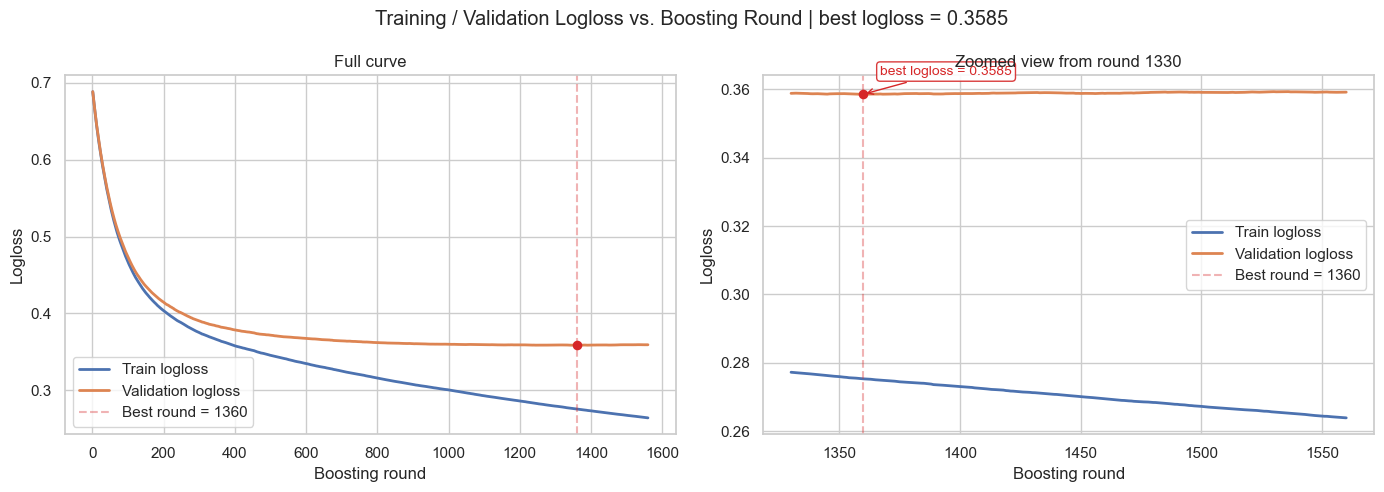

In [371]:

# evals_result is populated in the previous XGBoost training cell.
train_logloss = evals_result["validation_0"]["logloss"]
val_logloss = evals_result["validation_1"]["logloss"]
rounds = np.arange(1, len(train_logloss) + 1)
best_round = (xgb_model.best_iteration + 1) if xgb_model.best_iteration is not None else int(np.argmin(val_logloss) + 1)
best_idx = best_round - 1
best_val_logloss = val_logloss[best_idx]
zoom_start = max(1, best_round - 30)
zoom_mask = rounds >= zoom_start
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(rounds, train_logloss, label='Train logloss', linewidth=2)
axes[0].plot(rounds, val_logloss, label='Validation logloss', linewidth=2)
axes[0].axvline(best_round, color='tab:red', linestyle='--', alpha=0.35, label=f'Best round = {best_round}')
axes[0].scatter(best_round, best_val_logloss, color='tab:red', s=35, zorder=3)
axes[0].set_xlabel('Boosting round')
axes[0].set_ylabel('Logloss')
axes[0].set_title('Full curve')
axes[0].legend()

axes[1].plot(rounds[zoom_mask], np.array(train_logloss)[zoom_mask], label='Train logloss', linewidth=2)
axes[1].plot(rounds[zoom_mask], np.array(val_logloss)[zoom_mask], label='Validation logloss', linewidth=2)
axes[1].axvline(best_round, color='tab:red', linestyle='--', alpha=0.35, label=f'Best round = {best_round}')
axes[1].scatter(best_round, best_val_logloss, color='tab:red', s=35, zorder=3)
axes[1].annotate(
    f'best logloss = {best_val_logloss:.4f}',
    xy=(best_round, best_val_logloss),
    xytext=(12, 14),
    textcoords='offset points',
    fontsize=10,
    color='tab:red',
    bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='tab:red', alpha=0.9),
    arrowprops=dict(arrowstyle='->', color='tab:red', lw=1),
)
axes[1].set_xlabel('Boosting round')
axes[1].set_ylabel('Logloss')
axes[1].set_title(f'Zoomed view from round {zoom_start}')
axes[1].legend()

fig.suptitle(f'Training / Validation Logloss vs. Boosting Round | best logloss = {best_val_logloss:.4f}')
fig.tight_layout()
plt.show()

In [372]:
# Final run: retrain a k-bagged XGBoost ensemble on the full training set, write submission.csv, and submit from inside this notebook.
import subprocess
import sys
import shutil
from pathlib import Path
import xgboost as xgb

ENSEMBLE_K_VALUES = [10, 20, 30, 40]

def fmt_param(value):
    return str(value).replace(".", "p")

def build_xgb_preprocess(X_fit):
    numeric_features = X_fit.select_dtypes(include=["number"]).columns.tolist()
    categorical_features = X_fit.select_dtypes(exclude=["number"]).columns.tolist()
    return ColumnTransformer(
        transformers=[
            ("num", SimpleImputer(strategy="median"), numeric_features),
            (
                "cat",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore")),
                ]),
                categorical_features,
            ),
        ]
    )

def fit_kbag_member(X_fit, y_fit, X_target, k_value, n_estimators, *, eval_X=None, eval_y=None, random_state=42):
    xgb_preprocess = build_xgb_preprocess(X_fit)
    X_fit_pre = xgb_preprocess.fit_transform(X_fit)
    X_target_pre = xgb_preprocess.transform(X_target)
    xgb_feature_names = xgb_preprocess.get_feature_names_out()
    k_eff = max(1, min(k_value, X_fit_pre.shape[1]))
    selector = SelectKBest(score_func=f_regression, k=k_eff)
    X_fit_sel = selector.fit_transform(X_fit_pre, y_fit)
    X_target_sel = selector.transform(X_target_pre)
    selected_feature_names = xgb_feature_names[selector.get_support()]

    dfit = xgb.DMatrix(X_fit_sel, label=y_fit.astype(int))
    dtarget = xgb.DMatrix(X_target_sel)
    xgb_params = {
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "max_depth": MAX_DEPTH,
        "eta": LR,
        "subsample": SUBSAMPLE,
        "colsample_bytree": COLSAMPLE_BYTREE,
        "lambda": REG_LAMBDA,
        "seed": random_state,
        "verbosity": 0,
    }

    train_kwargs = {
        "params": xgb_params,
        "dtrain": dfit,
        "num_boost_round": n_estimators,
        "verbose_eval": False,
    }
    if eval_X is not None and eval_y is not None:
        X_eval_pre = xgb_preprocess.transform(eval_X)
        X_eval_sel = selector.transform(X_eval_pre)
        deval = xgb.DMatrix(X_eval_sel, label=eval_y.astype(int))
        train_kwargs["evals"] = [(dfit, "validation_0"), (deval, "validation_1")]
        train_kwargs["evals_result"] = {}
        train_kwargs["early_stopping_rounds"] = ESR

    booster = xgb.train(**train_kwargs)
    best_n_estimators = getattr(booster, "best_iteration", None)
    best_n_estimators = n_estimators if best_n_estimators is None else int(best_n_estimators) + 1
    target_proba = booster_predict_proba(booster, dtarget)

    return {
        "k_requested": k_value,
        "k_effective": k_eff,
        "selected_feature_names": selected_feature_names,
        "selected_feature_count": len(selected_feature_names),
        "best_n_estimators": max(1, best_n_estimators),
        "target_proba": target_proba,
    }

def search_best_threshold(y_true, probas, thresholds=None):
    if thresholds is None:
        thresholds = np.linspace(0.01, 0.99, 197)
    y_true = np.asarray(y_true).astype(int)
    probas = np.asarray(probas)
    best_threshold = 0.5
    best_acc = -1.0
    for threshold in thresholds:
        acc = accuracy_score(y_true, probas >= threshold)
        if acc > best_acc:
            best_acc = acc
            best_threshold = float(threshold)
    return best_threshold, best_acc

def build_oof_kbag_predictions(X, y, k_values, *, n_splits=5, random_state=42):
    X_work = X.reset_index(drop=True)
    y_work = np.asarray(y).astype(int)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    oof_probas = np.zeros(len(X_work), dtype=float)
    member_rounds = []
    for fold_idx, (fit_idx, eval_idx) in enumerate(skf.split(X_work, y_work)):
        X_fit = X_work.iloc[fit_idx].reset_index(drop=True)
        y_fit = y_work[fit_idx]
        X_eval = X_work.iloc[eval_idx].reset_index(drop=True)
        y_eval = y_work[eval_idx]
        fold_member_probas = []
        for member_idx, k_value in enumerate(k_values):
            member = fit_kbag_member(
                X_fit,
                y_fit,
                X_eval,
                k_value,
                N_ESTIMATORS,
                eval_X=X_eval,
                eval_y=y_eval,
                random_state=random_state + fold_idx * 100 + member_idx,
            )
            fold_member_probas.append(member["target_proba"])
            member_rounds.append(member["best_n_estimators"])
            print(
                f"fold={fold_idx + 1}/{n_splits} | k={member['k_effective']} | "
                f"val acc: {accuracy_score(y_eval, member['target_proba'] >= 0.5):.4f} | "
                f"best_n_estimators: {member['best_n_estimators']} | selected: {member['selected_feature_count']}"
            )
        fold_proba = np.mean(np.vstack(fold_member_probas), axis=0)
        oof_probas[eval_idx] = fold_proba
        print(f"fold={fold_idx + 1}/{n_splits} | ensemble acc @0.5: {accuracy_score(y_eval, fold_proba >= 0.5):.4f}")
    return oof_probas, member_rounds

print(f"OOF k-bagging members = {ENSEMBLE_K_VALUES}")
full_train_X = add_basic_features(train_data.drop(columns=["Transported"]).copy())
full_train_y = to_binary(train_data["Transported"])
test_raw = add_basic_features(test_data.copy())

oof_probas, oof_member_rounds = build_oof_kbag_predictions(
    full_train_X,
    full_train_y,
    ENSEMBLE_K_VALUES,
    n_splits=5,
    random_state=42,
)
oof_acc_05 = accuracy_score(np.asarray(full_train_y).astype(int), oof_probas >= 0.5)
best_threshold, oof_best_acc = search_best_threshold(full_train_y, oof_probas)
print(f"OOF k-ensemble | acc @0.5: {oof_acc_05:.4f}")
print(f"OOF k-ensemble | best threshold: {best_threshold:.4f} | oof acc: {oof_best_acc:.4f}")
print(f"OOF member best_n_estimators = {oof_member_rounds}")
final_n_estimators = max(1, int(np.round(np.median(oof_member_rounds))))
print(f"final_n_estimators (median of member best rounds) = {final_n_estimators}")

test_member_probas = []
for member_idx, k_value in enumerate(ENSEMBLE_K_VALUES):
    member = fit_kbag_member(
        full_train_X,
        full_train_y,
        test_raw,
        k_value,
        final_n_estimators,
        random_state=42 + member_idx,
    )
    test_member_probas.append(member["target_proba"])
    print(f"full-train k={member['k_effective']} | selected: {member['selected_feature_count']}")

test_proba = np.mean(np.vstack(test_member_probas), axis=0)
test_pred = (test_proba >= best_threshold).astype(bool)

k_tag = "-".join(str(k) for k in ENSEMBLE_K_VALUES)
submission_path = (
    f"submission_xgb_k{k_tag}_nt{final_n_estimators}_oofth{fmt_param(best_threshold)}"
    f"_lr{fmt_param(LR)}_md{MAX_DEPTH}_ss{fmt_param(SUBSAMPLE)}"
    f"_cs{fmt_param(COLSAMPLE_BYTREE)}_rl{fmt_param(REG_LAMBDA)}"
    f".csv"
)

sample_submission = pd.read_csv("./data/sample_submission.csv")
submission = sample_submission.copy()
submission["Transported"] = test_pred
submission.to_csv(submission_path, index=False)

print(submission.head())
print(f"saved to {submission_path} with shape {submission.shape}")

kaggle_exe = shutil.which("kaggle") or str(Path(sys.executable).with_name("kaggle"))
submit_cmd = [
    kaggle_exe,
    "competitions",
    "submit",
    "-c",
    "spaceship-titanic",
    "-f",
    submission_path,
    "-m",
    f"XGBoost early stopping / flat SelectKBest / PassengerId & Name features process / Spend features process / Interaction features / missingness / k-ensemble / OOF threshold search / age bins",
]
print("Running:", " ".join(submit_cmd))
try:
    result = subprocess.run(submit_cmd, check=True, text=True, capture_output=True)
    if result.stdout:
        print(result.stdout)
    if result.stderr:
        print(result.stderr)
except FileNotFoundError:
    print("kaggle CLI not found in this notebook kernel environment.")
except subprocess.CalledProcessError as exc:
    print("Kaggle submit failed.")
    if exc.stdout:
        print(exc.stdout)
    if exc.stderr:
        print(exc.stderr)
    raise


OOF k-bagging members = [10, 20, 30, 40]
fold=1/5 | k=10 | val acc: 0.8016 | best_n_estimators: 500 | selected: 10
fold=1/5 | k=20 | val acc: 0.8154 | best_n_estimators: 680 | selected: 20
fold=1/5 | k=30 | val acc: 0.8212 | best_n_estimators: 1318 | selected: 30
fold=1/5 | k=40 | val acc: 0.8171 | best_n_estimators: 889 | selected: 40
fold=1/5 | ensemble acc @0.5: 0.8183
fold=2/5 | k=10 | val acc: 0.7826 | best_n_estimators: 447 | selected: 10
fold=2/5 | k=20 | val acc: 0.7901 | best_n_estimators: 784 | selected: 20
fold=2/5 | k=30 | val acc: 0.8010 | best_n_estimators: 1038 | selected: 30
fold=2/5 | k=40 | val acc: 0.7987 | best_n_estimators: 995 | selected: 40
fold=2/5 | ensemble acc @0.5: 0.7970
fold=3/5 | k=10 | val acc: 0.7964 | best_n_estimators: 508 | selected: 10
fold=3/5 | k=20 | val acc: 0.8068 | best_n_estimators: 774 | selected: 20
fold=3/5 | k=30 | val acc: 0.8120 | best_n_estimators: 1121 | selected: 30
fold=3/5 | k=40 | val acc: 0.8131 | best_n_estimators: 1181 | select